In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import sqlite3


In [4]:
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
        productname TEXT,
        unitsold INTEGER,
        revenue REAL,
        price REAL
    )
''')
conn.commit()
print("Sales table created successfully.")


Sales table created successfully.


In [5]:
sales_data = [
    ('Shampoo', 150, 22500.0, 150.0),
    ('Soap', 300, 18000.0, 60.0),
    ('Toothpaste', 200, 24000.0, 120.0),
    ('Hair Oil', 100, 20000.0, 200.0)
]
cursor.executemany('''
    INSERT INTO sales (productname, unitsold, revenue, price)
    VALUES (?, ?, ?, ?)
''', sales_data)
conn.commit()
print("Sample data inserted successfully.")

Sample data inserted successfully.


In [6]:
cursor.execute("SELECT * FROM sales")
rows = cursor.fetchall()

for row in rows:
    print(row)

('Shampoo', 150, 22500.0, 150.0)
('Soap', 300, 18000.0, 60.0)
('Toothpaste', 200, 24000.0, 120.0)
('Hair Oil', 100, 20000.0, 200.0)


In [7]:
cursor.execute("SELECT SUM(revenue) FROM sales")
total_revenue = cursor.fetchone()[0]
print("Total Revenue:", total_revenue)

Total Revenue: 84500.0


In [8]:
cursor.execute("SELECT SUM(unitsold) FROM sales")
total_units_sold = cursor.fetchone()[0]
print("Total Units Sold:", total_units_sold)

Total Units Sold: 750


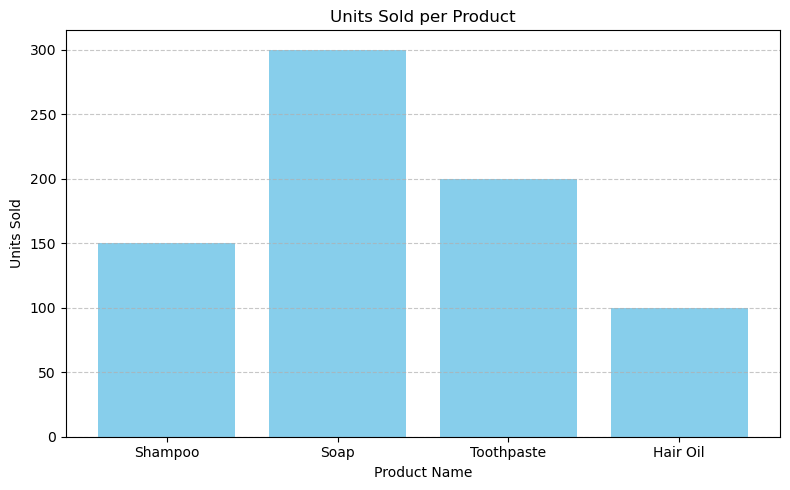

In [9]:
cursor.execute("SELECT productname, unitsold FROM sales")
data = cursor.fetchall()
products = [row[0] for row in data]
units = [row[1] for row in data]
plt.figure(figsize=(8, 5))
plt.bar(products, units, color='skyblue')
plt.title('Units Sold per Product')
plt.xlabel('Product Name')
plt.ylabel('Units Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()